In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Hand-in assignment 1

In [46]:
L = 0.75 #m 
Ls = 5 #m
d = 1/2 * 0.75 #m
m = 2 #kg
J_e = 0.1 #kgm^2
k = 5000 #N/m

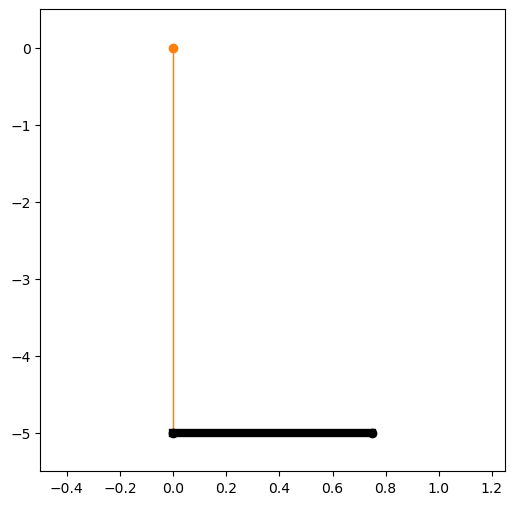

In [47]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-0.5, 0.5+ L)
ax.set_ylim(-(0.5 + Ls), 0.5)
ax.plot(0, 0, 'o', color='C1');
ax.plot([0, 0], [0, -Ls], color='C1', linewidth=1);
ax.plot(0, -Ls, 'o', color='black');
ax.plot(L, -Ls, 'o', color='black');
ax.plot([0, L], [-Ls, -Ls], color='black', linewidth=6);

$$\Sigma F_x = m (\ddot{x_b} + d(-cos(\phi) \cdot \dot{\phi}^2 - sin(\phi) \ddot{\phi})) = F_{1x}$$
$$\Sigma F_y = m (\ddot{y_b} + d(-sin(\phi) \cdot \dot{\phi}^2 + cos(\phi) \ddot{\phi})) = F_{1y} - F_g$$
$$\Sigma M_{/C} = J_{/C} \ddot{\phi}$$

$$M = \vec{r} \times \vec{F} $$

$$\vec{r} = 
\begin{pmatrix}
    x_b - x_c \\
    y_b - y_c \\
\end{pmatrix}
$$

$$\vec{b} = 
\begin{pmatrix}
    x_b \\
    y_b \\
\end{pmatrix}
$$

$$\vec{F} = 
\begin{pmatrix}
    F_x \\
    F_y \\
\end{pmatrix}
= \frac{-\vec{b}}{L} \cdot  \lvert F \rvert  = -(\Delta{L}\cdot k) \frac{1}{L} \cdot \vec{b} =  -(\Delta{L}\cdot k) \frac{1}{\lvert \vec{b} \rvert} \cdot \vec{b}$$

<!-- $$1 -->

In [48]:
def ForceB(x, y, L = Ls, k = k):
    dol = np.sqrt(x**2 + y**2)
    if dol > L:
        F = (dol-L) * k
        Fx = F * -x / np.sqrt(x**2 + y**2)
        Fy = F * -y / np.sqrt(x**2 + y**2)
        return Fx, Fy
    else:
        return 0, 0

In [49]:
print(f'Length0: {Ls}')
xs = 0
ys = -5.00196200
print(f'Length1: {np.sqrt(xs**2 + ys**2)}')
ForceB(xs, ys)
print(f'Force x: {ForceB(xs, ys)[0]:.3f}')
print(f'Force y: {ForceB(xs, ys)[1]:.3f}')

Length0: 5
Length1: 5.001962
Force x: 0.000
Force y: 9.810


Force x: 0.000
Force y: 9.810


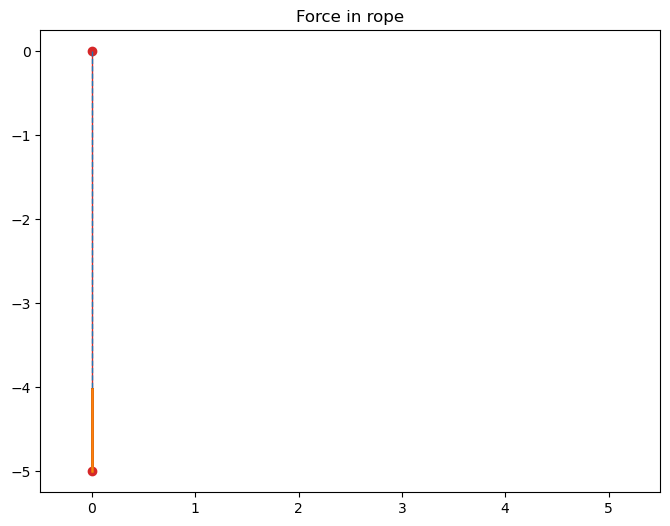

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Force in rope')
ax.set_xlim(-0.5+xs, 0.5+ Ls)

ax.plot([0, xs], [0, ys], 'C3o-', linewidth=1);
ax.plot([0, 0], [0, -Ls], 'C0--', linewidth=1);

scale1=10
Fx, Fy = ForceB(xs, ys)

ax.plot([xs, xs + Fx/scale1], [ys, ys + Fy/scale1], color='black', linewidth=2);
# draw force by components x and y
ax.plot([xs, xs + Fx/scale1], [ys, ys], color='C1', linewidth=2);
ax.plot([xs, xs], [ys, ys + Fy/scale1], color='C1', linewidth=2);
print(f'Force x: {Fx:.3f}')
print(f'Force y: {Fy:.3f}')

### 2 How many DoF
DOF:2

### 3 Equations of motions 
for $t=0$

In [51]:
phi, dphi = 0, 0
Fx = 0
J_T = J_e
g = 9.81
Fy = m*g/2

A = [[m, 0, -1/2 * L * m*np.sin(phi)],
    [0, m, 1/2 * L * m*np.cos(phi)],
    [0, 0, -J_T]]

b = [[1/2 * L * m*np.cos(phi) * dphi**2 + Fx],
    [1/2 * L * m*np.sin(phi) * dphi**2 +Fy - m *g],
    [m*g*L/4]] #Fy times the distance 1/2 L

x = np.linalg.solve(A, b)
print(f'ddx = {x[0][0]:.4f} m/s^2')
print(f'ddy = {x[1][0]:.4f} m/s^2')
print(f'ddphi = {x[2][0]:.4f} rad/s^2')

ddx = 0.0000 m/s^2
ddy = 8.8903 m/s^2
ddphi = -36.7875 rad/s^2


### 5 Simulation
$t: 0s \rightarrow 5 s$

In [58]:
t = np.arange(0, 8, 0.002)
dt = t[1] - t[0]
print(f'dt = {dt:.4f} s')

dt = 0.0020 s


In [59]:
V = np.zeros((6, len(t))) # x, y, phi, dx, dy, dphi
F = np.zeros((2, len(t))) # Fx, Fy
sol = np.zeros((3, len(t))) # x, y, phi, dx, dy, dphi

print(f'm = {m:.2f} kg')
print(f'k = {k:.2f} N/m')
print(f'y[0] = {-Ls-(1/2 * m*g/k):.8f} m')
V[1][0] = -Ls-1/2 * m*g/k
F[:, 0] = ForceB(V[0][0], V[1][0])

F[:, :3]
# V[1::2, :3] = 1
# V[:, :3]

m = 2.00 kg
k = 5000.00 N/m
y[0] = -5.00196200 m


array([[-0.  ,  0.  ,  0.  ],
       [ 9.81,  0.  ,  0.  ]])

x 	 y 		 phi 		 dx 		 dy 		 dphi 		 Fx 		 Fy

0.0000 	 -5.0020 	 0.0000 	 0.0000 	 0.0000 	 0.0000 	 -0.00 		 9.81
0.0000 	 -5.0020 	 0.0000 	 0.0000 	 0.0178 	 -0.0736 	 -0.00 		 9.81
0.0000 	 -5.0019 	 -0.0001 	 0.0000 	 0.0356 	 -0.1471 	 -0.00 		 9.63
0.0000 	 -5.0019 	 -0.0004 	 0.0000 	 0.0527 	 -0.2194 	 -0.00 		 9.28
0.0000 	 -5.0017 	 -0.0009 	 0.0001 	 0.0684 	 -0.2890 	 -0.00 		 8.75
0.0000 	 -5.0016 	 -0.0015 	 0.0002 	 0.0822 	 -0.3546 	 -0.00 		 8.07
0.0000 	 -5.0014 	 -0.0022 	 0.0003 	 0.0933 	 -0.4151 	 -0.00 		 7.24
0.0000 	 -5.0013 	 -0.0030 	 0.0005 	 0.1013 	 -0.4694 	 -0.00 		 6.31
0.0000 	 -5.0011 	 -0.0039 	 0.0007 	 0.1057 	 -0.5168 	 -0.00 		 5.30
0.0000 	 -5.0008 	 -0.0050 	 0.0009 	 0.1063 	 -0.5565 	 -0.00 		 4.24
0.0000 	 -5.0006 	 -0.0061 	 0.0012 	 0.1029 	 -0.5883 	 -0.00 		 3.18
0.0000 	 -5.0004 	 -0.0073 	 0.0015 	 0.0953 	 -0.6121 	 -0.00 		 2.15
0.0000 	 -5.0002 	 -0.0085 	 0.0019 	 0.0839 	 -0.6283 	 -0.00 		 1.20
0.0000 	 -5.0001 	 -0.0097 	 0.002

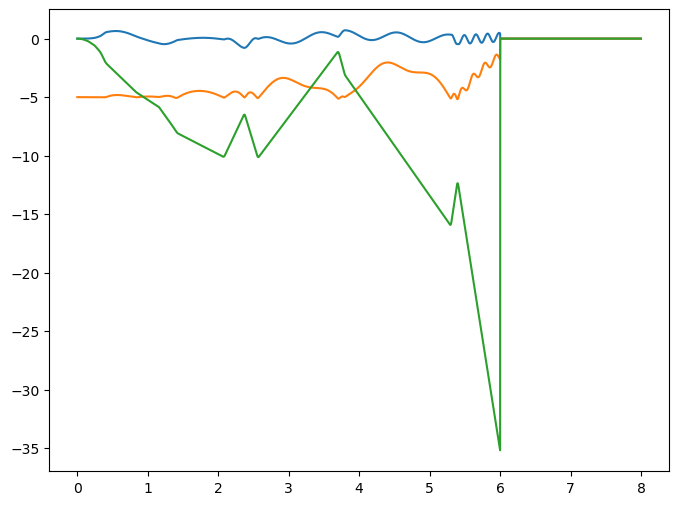

In [60]:
# print(f'step {0}')
# print(f'x = {V[0][0]:.4f} m')
# print(f'y = {V[1][0]:.4f} m')
# print(f'phi = {V[2][0]:.4f} rad')
# print(f'dx = {V[3][0]:.4f} m/s')
# print(f'dy = {V[4][0]:.4f} m/s')
# print(f'dphi = {V[5][0]:.4f} rad/s')
# print(f'ddx = {sol[0][0]:.4f} m/s^2')
# print(f'ddy = {sol[1][0]:.4f} m/s^2')
# print(f'ddphi = {sol[2][0]:.4f} rad/s^2')
# print()

print(f'x \t y \t\t phi \t\t dx \t\t dy \t\t dphi \t\t Fx \t\t Fy')
print()
for i in np.arange(3000):
    x, y, phi, dx, dy, dphi = V[:, i]
    Fx, Fy = F[:, i]
    A = [[m, 0, -1/2 * L * m*np.sin(phi)],
        [0, m, 1/2 * L * m*np.cos(phi)],
        [0, 0, -J_T]]

    b = [[1/2 * L * m*np.cos(phi) * dphi**2 + Fx],
        [1/2 * L * m*np.sin(phi) * dphi**2 + Fy - m*g],
        [+Fx *L/2 * np.sin(phi)+Fy *L/2 * np.cos(phi)]]

    x = np.linalg.solve(A, b)
    sol[:, i] = x[:, 0]
    V[:3, i+1] = V[:3, i] + V[3:, i] * dt
    V[3:, i+1] = V[3:, i] + x[:, 0] * dt
    F[:, i+1] = ForceB(V[0][i+1], V[1][i+1])

    # print(f'step {i+1}')
    # print(f'x = {V[0][i+1]:.4f} m')
    # print(f'y = {V[1][i+1]:.4f} m')
    # print(f'phi = {V[2][i+1]:.4f} rad')
    # print(f'dx = {V[3][i+1]:.4f} m/s')
    # print(f'dy = {V[4][i+1]:.4f} m/s')
    # print(f'dphi = {V[5][i+1]:.4f} rad/s')
    # print(f'ddx = {sol[0][i+1]:.4f} m/s^2')
    # print(f'ddy = {sol[1][i+1]:.4f} m/s^2')
    # print(f'ddphi = {sol[2][i+1]:.4f} rad/s^2')
    # print(f'Force x: {F[0][i+1]:.3f}')
    # print(f'Force y: {F[1][i+1]:.3f}')
    # print()
    

    print(f'{V[0, i]:.4f} \t {V[1, i]:.4f} \t {V[2, i]:.4f} \t {V[3, i]:.4f} \t {V[4, i]:.4f} \t {V[5, i]:.4f} \t {F[0, i]:.2f} \t\t {F[1, i]:.2f}')

print(f'ddx \t\t ddy \t\t ddphi')
print()
j = 0
print(f'{sol[0, j]:.3f} \t {sol[1, j]:.3f} \t {sol[2, j]:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t, V[0], label='x')
ax.plot(t, V[1], label='y')
ax.plot(t, V[2], label='phi')

In [55]:
dt* 8.8903

0.0177806

ddx = 0.0000 m/s^2
ddy = 8.8903 m/s^2
ddphi = -36.7875 rad/s^2